# Нейронная сеть с TensorFlow/Keras
Распознавание рукописных цифр (MNIST)

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

C:\Users\Ruslan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow: 2.20.0


## 1. Загрузка данных MNIST

In [2]:
# MNIST - 70000 изображений рукописных цифр 28x28 пикселей
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print('Обучающая выборка:', x_train.shape)
print('Тестовая выборка:', x_test.shape)
print('Классы:', np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Обучающая выборка: (60000, 28, 28)
Тестовая выборка: (10000, 28, 28)
Классы: [0 1 2 3 4 5 6 7 8 9]


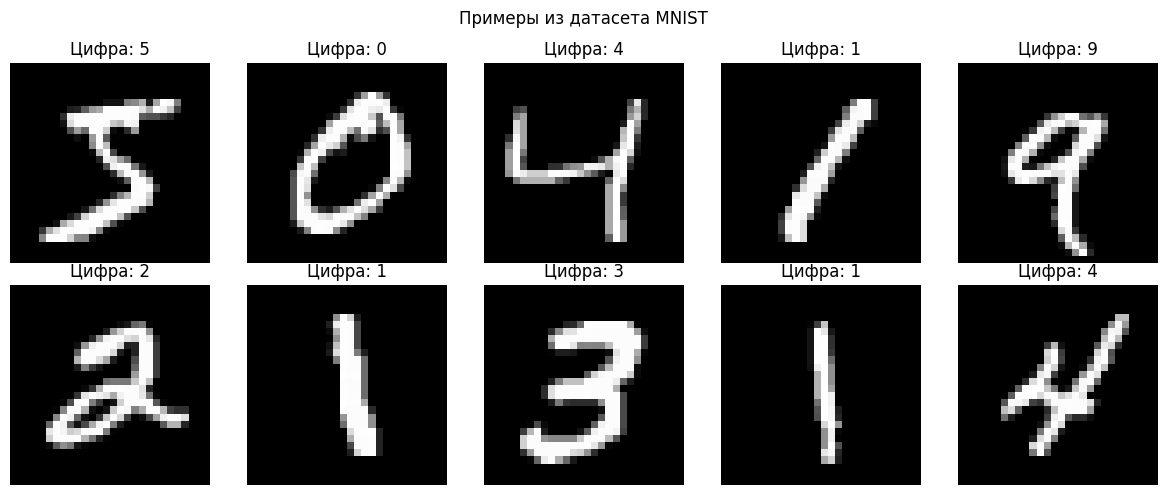

In [3]:
# Посмотрим на примеры
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f'Цифра: {y_train[i]}')
    ax.axis('off')
plt.suptitle('Примеры из датасета MNIST')
plt.tight_layout()
plt.show()

## 2. Подготовка данных

In [4]:
# Нормализация (0-255 -> 0-1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Преобразуем в вектор (28x28 -> 784)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print('Форма данных:', x_train_flat.shape)

Форма данных: (60000, 784)


## 3. Создание модели

In [5]:
# Простая полносвязная нейросеть
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax', name='output')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Компиляция модели
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Модель скомпилирована!')

Модель скомпилирована!


## 4. Обучение модели

In [8]:
# Обучение (5 эпох)
history = model.fit(
    x_train_flat, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9719 - loss: 0.0907 - val_accuracy: 0.9783 - val_loss: 0.0701
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9747 - loss: 0.0798 - val_accuracy: 0.9817 - val_loss: 0.0664
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9767 - loss: 0.0734 - val_accuracy: 0.9815 - val_loss: 0.0691
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9785 - loss: 0.0677 - val_accuracy: 0.9775 - val_loss: 0.0759
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9786 - loss: 0.0664 - val_accuracy: 0.9813 - val_loss: 0.0684


## 5. Визуализация обучения

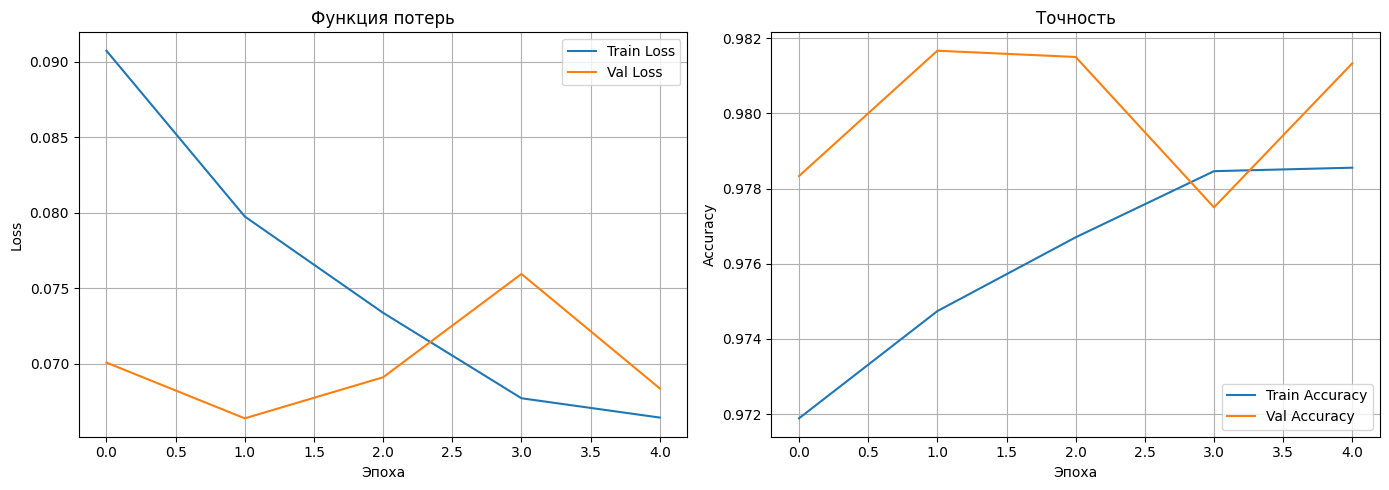

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Функция потерь')
axes[0].legend()
axes[0].grid(True)

# График точности
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Точность')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 6. Оценка на тестовых данных

In [10]:
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)
print(f'Точность на тесте: {test_accuracy * 100:.2f}%')

Точность на тесте: 97.70%


## 7. Предсказания

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


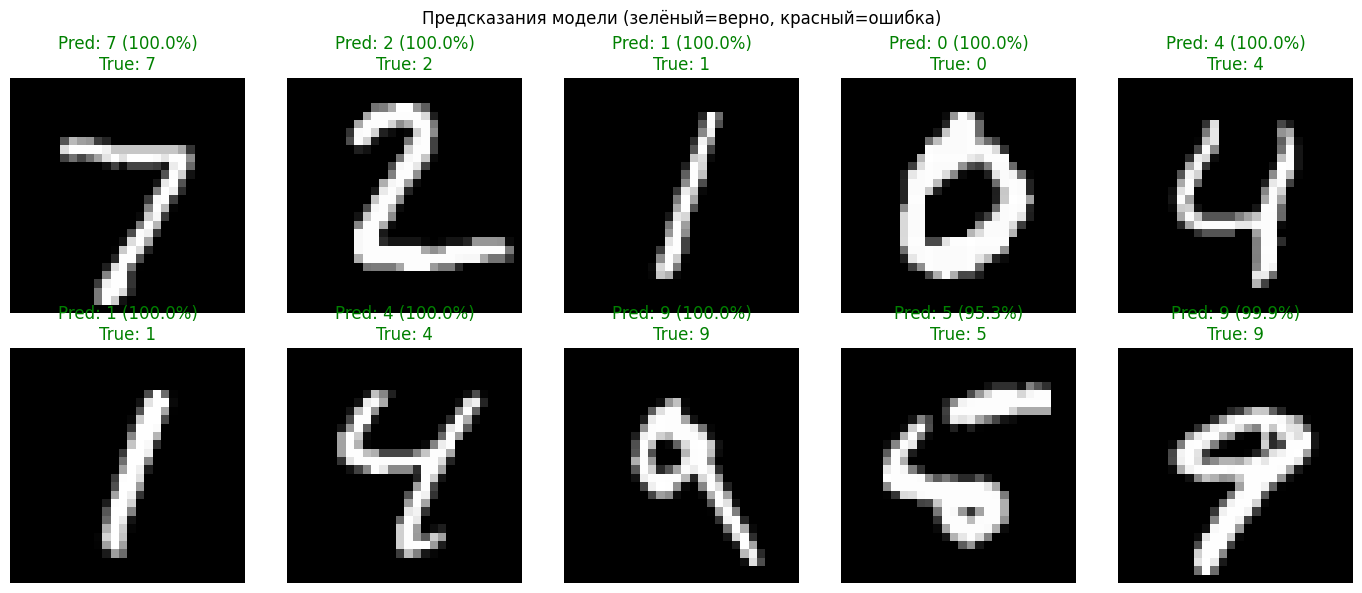

In [11]:
# Предсказания для тестовых данных
predictions = model.predict(x_test_flat[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i], cmap='gray')
    pred = np.argmax(predictions[i])
    conf = predictions[i][pred] * 100
    color = 'green' if pred == y_test[i] else 'red'
    ax.set_title(f'Pred: {pred} ({conf:.1f}%)\nTrue: {y_test[i]}', color=color)
    ax.axis('off')
plt.suptitle('Предсказания модели (зелёный=верно, красный=ошибка)')
plt.tight_layout()
plt.show()

## 8. Матрица ошибок

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


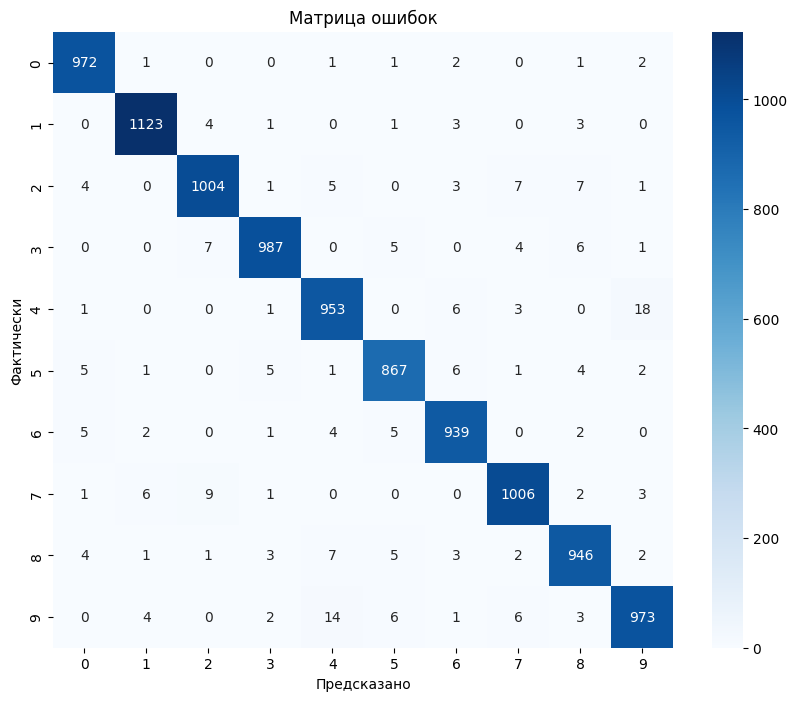

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Предсказания для всего теста
y_pred = np.argmax(model.predict(x_test_flat), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.title('Матрица ошибок')
plt.show()

## 9. Сохранение модели

In [13]:
# Сохранить модель
model.save('mnist_model.keras')
print('Модель сохранена в mnist_model.keras')

# Загрузить модель (пример)
# loaded_model = keras.models.load_model('mnist_model.keras')

Модель сохранена в mnist_model.keras


## 10. Свёрточная нейросеть (CNN)

In [14]:
# Подготовка данных для CNN (добавляем канал)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# CNN модель
cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Обучение CNN
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

cnn_history = cnn_model.fit(
    x_train_cnn, y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8944 - loss: 0.3383 - val_accuracy: 0.9823 - val_loss: 0.0533
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9637 - loss: 0.1255 - val_accuracy: 0.9882 - val_loss: 0.0449
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9711 - loss: 0.0966 - val_accuracy: 0.9872 - val_loss: 0.0423


In [16]:
# Оценка CNN
cnn_loss, cnn_accuracy = cnn_model.evaluate(x_test_cnn, y_test, verbose=0)
print(f'Точность CNN: {cnn_accuracy * 100:.2f}%')
print(f'Точность простой сети: {test_accuracy * 100:.2f}%')

Точность CNN: 98.79%
Точность простой сети: 97.70%
